In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, IntSlider, FloatSlider
%matplotlib ipympl

In [2]:
sqrt3 = np.sqrt(3)
K = 1/(2.4*np.pi)
log_K = np.log(K)

def log_prob(x,y):
    A = np.exp(-2.5*((x-1.5*sqrt3)**2+(y-1.5)**2))
    B = np.exp(-2.5*((x+1.5*sqrt3)**2+(y-1.5)**2))
    C = np.exp(-2.5*(x**2+(y+3)**2))
    return log_K+np.log(A+B+C)

def grad_log_prob(x,y):
    A = np.exp(-2.5*((x-1.5*sqrt3)**2+(y-1.5)**2))
    B = np.exp(-2.5*((x+1.5*sqrt3)**2+(y-1.5)**2))
    C = np.exp(-2.5*(x**2+(y+3)**2))
    sum_ABC = A+B+C
    dx = (-5/sum_ABC)*(A*(x-1.5*sqrt3)+B*(x+1.5*sqrt3)+C*x)
    dy = (-5/sum_ABC)*(A*(y-1.5)+B*(y-1.5)+C*(y+3))
    return np.array([dx,dy])

In [2]:
# This is the function we defined. We can change it into other functions.
def log_prob(x,y):
    return -0.5*(x**2+y**2)

def grad_log_prob(x,y):
    dx = -x
    dy = -y
    return np.array([dx,dy])

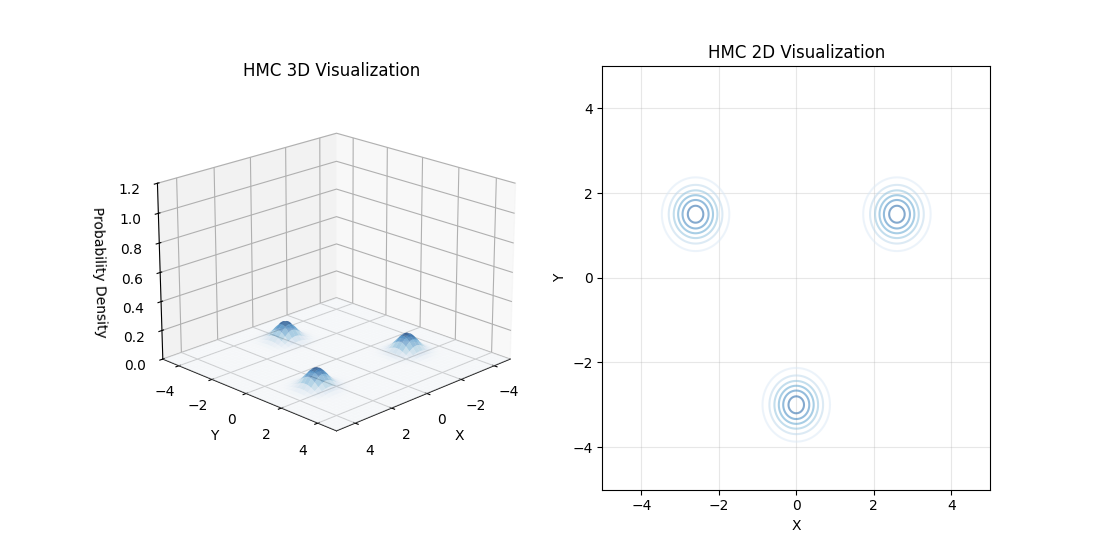

In [3]:
x_range = np.linspace(-5,5,500)
y_range = np.linspace(-5,5,500)
X,Y = np.meshgrid(x_range,y_range)
Z = np.exp(log_prob(X,Y))

fig = plt.figure(figsize=(11, 5.5))
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X,Y,Z,cmap='Blues',alpha=0.5,edgecolor='none')
ax.set_xlabel('X',fontsize=10)
ax.set_ylabel('Y',fontsize=10)
ax.set_zlabel('Probability Density',fontsize=10)
ax.set_title('HMC 3D Visualization',fontsize=12)
ax.view_init(elev=20,azim=45)
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(0,1.2)

ax2d = fig.add_subplot(122)
ax2d.contour(X,Y,Z,cmap='Blues',alpha=0.5)
ax2d.set_xlabel('X',fontsize=10)
ax2d.set_ylabel('Y',fontsize=10)
ax2d.set_title('HMC 2D Visualization',fontsize=12)
ax2d.set_xlim(-5,5)
ax2d.set_ylim(-5,5)
ax2d.grid(alpha=0.3)

In [4]:
last_q = np.array(np.random.uniform(low=-3, high=3, size=2))
q_current = None 
p_current = None
path = None
trajectory_line = None
current_point = None
trajectory_line_2d = None
current_point_2d = None
result_text = None 

# These are the features we defined. We can change them into other values.
leapfrog_steps = 5
step_size = 0.3
times = 20

In [5]:
def reset_hmc():
    global last_q, q_current,p_current,path,trajectory_line,current_point
    q_current = last_q.copy().astype(np.float64)
    p_current = np.random.randn(2)  
    path = [q_current.copy()]         
    if trajectory_line:
        trajectory_line.remove()
    if current_point:
        current_point.remove()
    trajectory_line = None
    current_point = None

    fig.canvas.draw()
    fig.canvas.flush_events()
    
    return q_current,p_current

In [6]:
def update_leapfrog(frame,q_current,p_current,path):
    global trajectory_line,current_point,step_size,trajectory_line_2d,current_point_2d
    
    p_current += step_size/2*grad_log_prob(*q_current)
    q_current += step_size*p_current
    p_current += step_size/2*grad_log_prob(*q_current)
    path.append(q_current.copy())
   
    path_arr = np.array(path)
    z_vals = np.exp(log_prob(path_arr[:,0],path_arr[:,1]))
    
    if trajectory_line:
        trajectory_line.remove()
    trajectory_line = ax.plot(path_arr[:,0],path_arr[:,1],z_vals,color='#FF4500',marker='o',markersize=8,linewidth=4)[0]
    
    if current_point:
        current_point.remove()
    current_point = ax.scatter(q_current[0],q_current[1],z_vals[-1],color='#FFFF00',s=200,zorder=100,edgecolor='black',linewidth=1) 

    if trajectory_line_2d:
        trajectory_line_2d.remove()
    trajectory_line_2d = ax2d.plot(path_arr[:,0],path_arr[:,1],color='#FF4500',marker='o',markersize=8,linewidth=4)[0]
    
    if current_point_2d:
        current_point_2d.remove()
    current_point_2d = ax2d.scatter(q_current[0],q_current[1],color='#FFFF00',s=200,zorder=100,edgecolor='black',linewidth=1)

    fig.canvas.draw()
    fig.canvas.flush_events()
    
    return q_current,p_current,path

In [7]:
def run_hmc(leapfrog_steps,step_size):
    global last_q,q_current,p_current,path,result_text
    q_initial, p_initial = reset_hmc()  
    original_q_initial = q_initial.copy()
    original_p_initial = p_initial.copy()
    
    for frame in range(leapfrog_steps):
        q_current,p_current,path = update_leapfrog(frame,q_current,p_current,path)
        time.sleep(0.1)
        fig.canvas.draw()

    H_initial = -log_prob(*original_q_initial)+0.5*np.sum(original_p_initial**2)
    H_new = -log_prob(*q_current)+0.5*np.sum(p_current**2)
    accept_prob = np.exp(min(0,H_initial-H_new))

    if result_text:
        result_text.remove()
    if np.random.rand() < accept_prob:
        result = f"Accept! P:{accept_prob:.2f}"
        color = 'green'
        last_q = q_current.copy()
    else:
        result = f"Deny! P: {accept_prob:.2f}"
        color = 'red'
        last_q = q_initial.copy()

    final_point = last_q.copy()
    ax.scatter(final_point[0],final_point[1],np.exp(log_prob(final_point[0],final_point[1])),color='purple',s=100,alpha=0.5,zorder=50)
    ax2d.scatter(final_point[0],final_point[1],color='purple',s=100,alpha=0.5,zorder=50)

    result_text = ax.text2D(0.05,0.95,result,transform=ax.transAxes,fontsize=12,color=color,bbox=dict(boxstyle='round',facecolor='white'))
    fig.canvas.draw()

In [8]:
for _ in range(times):
    run_hmc(leapfrog_steps,step_size)